# Лабораторная работа №7

**Тема:** Анализ и прогнозирование временного ряда.  
**Цель:** изучение основных методов анализа и прогнозирования временных рядов.

В работе используется датасет `agriculture.csv`. На его основе формируется временной ряд по годам для выбранного вида сельскохозяйственной продукции. Далее строятся прогнозы методами ARIMA, символьной регрессии и методами семейства МГУА при доступности библиотеки `gmdh`.

## 1. Установка и импорт библиотек

In [1]:
!pip -q install statsmodels gplearn gmdh

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 80.2 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for gmdh
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (gmdh)


In [2]:
!pip install gplearn

  Using cached gplearn-0.4.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached gplearn-0.4.3-py3-none-any.whl (40 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.arima.model import ARIMA
from gplearn.genetic import SymbolicRegressor

plt.rcParams['figure.figsize'] = (10, 5)

## 2. Загрузка и предварительная очистка данных

In [4]:
# Загрузка данных
df = pd.read_csv('agriculture.csv', sep=';', encoding='cp1251')

# Очистка названий столбцов
df.columns = df.columns.str.strip()

# Приведение строковых признаков к единому виду
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Удаление лишнего суффикса в названии продукции
df['Наименование вида сельхоз. продукции'] = (
    df['Наименование вида сельхоз. продукции']
    .str.replace(', тыс. штук', '', regex=False)
)

# Функция преобразования строковых чисел в float
def convert_to_float(series):
    series = series.astype(str).str.replace(',', '.', regex=False).str.strip()
    return pd.to_numeric(series, errors='coerce')

# Преобразование числовых столбцов
df['Показатель, тыс. ед.'] = convert_to_float(df['Показатель, тыс. ед.'])
df['Доля'] = convert_to_float(df['Доля'])
df['Темп роста, %'] = convert_to_float(df['Темп роста, %'])
df['Год'] = pd.to_numeric(df['Год'], errors='coerce')

print(df.head())
print(df.info())
print(df.isna().sum())

            Сектор Наименование вида сельхоз. продукции   Год  \
0  растениеводство                   капуста всех видов  1999   
1  растениеводство                   капуста всех видов  2000   
2  растениеводство                   капуста всех видов  2001   
3  растениеводство                   капуста всех видов  2002   
4  растениеводство                   капуста всех видов  2003   

   Показатель, тыс. ед.      Доля  Темп роста, % Категория  
0                166.18  0.002884            NaN   высокий  
1                156.63  0.002820      -5.746781   высокий  
2                146.04  0.002609      -6.761157   высокий  
3                140.55  0.002487      -3.759244   высокий  
4                137.69  0.002613      -2.034863   высокий  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 7 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0 

## 3. Формирование временного ряда

Так как исходный датасет содержит разные виды сельскохозяйственной продукции, для прогнозирования нужно сформировать один временной ряд.  
В работе выбирается самый часто встречающийся вид продукции, затем значения агрегируются по годам.

In [5]:
print('Наиболее часто встречающиеся виды продукции:')
print(df['Наименование вида сельхоз. продукции'].value_counts().head(20))

product_name = df['Наименование вида сельхоз. продукции'].value_counts().idxmax()
print('\nВыбранный вид продукции:', product_name)

ts_df = df[df['Наименование вида сельхоз. продукции'] == product_name].copy()

ts_df = (
    ts_df
    .groupby('Год', as_index=False)['Показатель, тыс. ед.']
    .mean()
    .sort_values('Год')
)

ts_df = ts_df.dropna().reset_index(drop=True)

print('\nСформированный временной ряд:')
print(ts_df)

Наиболее часто встречающиеся виды продукции:
Наименование вида сельхоз. продукции
капуста всех видов       26
лен-долгунец             26
подсолнечник на зерно    26
горчица                  26
гречиха                  26
зернобобовые культуры    26
кабачки                  26
картофель                26
кукуруза                 26
лук репчатый             26
морковь столовая         26
овёс                     26
огурцы                   26
помидоры                 26
просо                    26
прочие овощи             26
пшеница                  26
рапс озимый              26
рапс яровой (кольза)     26
рис                      26
Name: count, dtype: int64

Выбранный вид продукции: капуста всех видов

Сформированный временной ряд:
     Год  Показатель, тыс. ед.
0   1999            166.180000
1   2000            156.630000
2   2001            146.040000
3   2002            140.550000
4   2003            137.690000
5   2004            123.340000
6   2005            113.960000
7   2006

## 4. Визуализация временного ряда

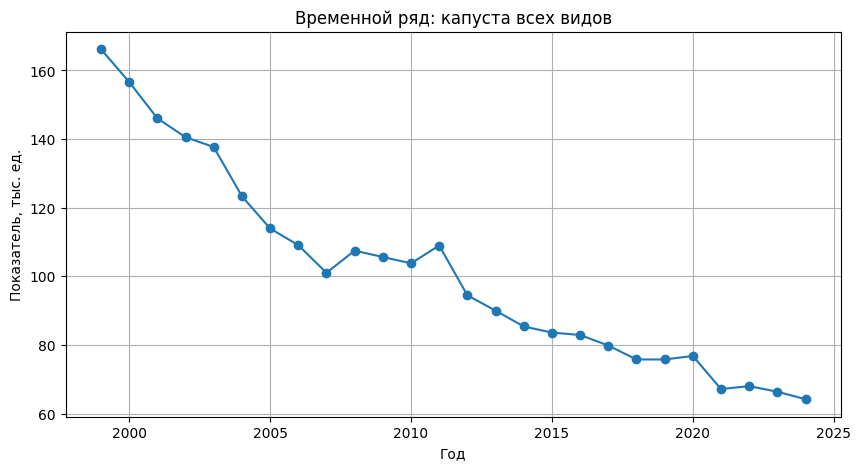

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(ts_df['Год'], ts_df['Показатель, тыс. ед.'], marker='o')
plt.title(f'Временной ряд: {product_name}')
plt.xlabel('Год')
plt.ylabel('Показатель, тыс. ед.')
plt.grid(True)
plt.show()

## 5. Основные характеристики временного ряда

In [7]:
print('Основные характеристики временного ряда:')
print(ts_df['Показатель, тыс. ед.'].describe())

print('\nКоличество наблюдений:', len(ts_df))
print('Минимальный год:', ts_df['Год'].min())
print('Максимальный год:', ts_df['Год'].max())

ts_df['Изменение'] = ts_df['Показатель, тыс. ед.'].diff()
ts_df['Темп_изменения_%'] = ts_df['Показатель, тыс. ед.'].pct_change() * 100

print('\nРяд с изменениями по годам:')
print(ts_df)

Основные характеристики временного ряда:
count     26.000000
mean     101.189521
std       29.169341
min       64.205487
25%       77.581500
50%       97.767500
75%      112.742500
max      166.180000
Name: Показатель, тыс. ед., dtype: float64

Количество наблюдений: 26
Минимальный год: 1999
Максимальный год: 2024

Ряд с изменениями по годам:
     Год  Показатель, тыс. ед.  Изменение  Темп_изменения_%
0   1999            166.180000        NaN               NaN
1   2000            156.630000  -9.550000         -5.746781
2   2001            146.040000 -10.590000         -6.761157
3   2002            140.550000  -5.490000         -3.759244
4   2003            137.690000  -2.860000         -2.034863
5   2004            123.340000 -14.350000        -10.421962
6   2005            113.960000  -9.380000         -7.604994
7   2006            109.090000  -4.870000         -4.273429
8   2007            101.047000  -8.043000         -7.372811
9   2008            107.492000   6.445000          6.37

## 6. Разделение временного ряда на обучающую и тестовую выборки

Для временных рядов нельзя случайно перемешивать данные, так как важен порядок наблюдений во времени.  
Поэтому первые 80% наблюдений используются для обучения, а последние 20% — для тестирования.

Обучающая выборка:
     Год  Показатель, тыс. ед.  Изменение  Темп_изменения_%
0   1999               166.180        NaN               NaN
1   2000               156.630     -9.550         -5.746781
2   2001               146.040    -10.590         -6.761157
3   2002               140.550     -5.490         -3.759244
4   2003               137.690     -2.860         -2.034863
5   2004               123.340    -14.350        -10.421962
6   2005               113.960     -9.380         -7.604994
7   2006               109.090     -4.870         -4.273429
8   2007               101.047     -8.043         -7.372811
9   2008               107.492      6.445          6.378220
10  2009               105.645     -1.847         -1.718267
11  2010               103.794     -1.851         -1.752094
12  2011               108.987      5.193          5.003179
13  2012                94.488    -14.499        -13.303422
14  2013                90.008     -4.480         -4.741343
15  2014             

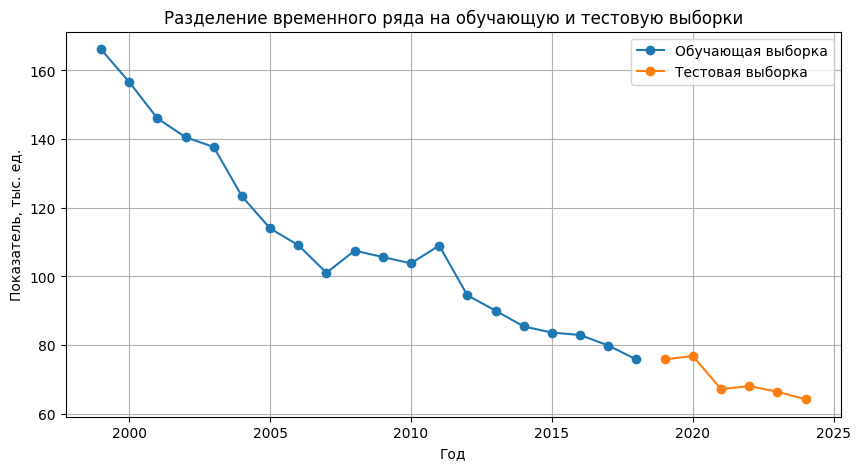

In [8]:
train_size = int(len(ts_df) * 0.8)

train = ts_df.iloc[:train_size].copy()
test = ts_df.iloc[train_size:].copy()

print('Обучающая выборка:')
print(train)

print('\nТестовая выборка:')
print(test)

plt.figure(figsize=(10, 5))
plt.plot(train['Год'], train['Показатель, тыс. ед.'], marker='o', label='Обучающая выборка')
plt.plot(test['Год'], test['Показатель, тыс. ед.'], marker='o', label='Тестовая выборка')
plt.title('Разделение временного ряда на обучающую и тестовую выборки')
plt.xlabel('Год')
plt.ylabel('Показатель, тыс. ед.')
plt.legend()
plt.grid(True)
plt.show()

## 7. Прогнозирование методом ARIMA

ARIMA — авторегрессионный метод прогнозирования временных рядов. Он использует прошлые значения ряда и учитывает дифференцирование для работы с трендом.

In [9]:
arima_model = ARIMA(train['Показатель, тыс. ед.'], order=(1, 1, 1))
arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(steps=len(test))
test['ARIMA_forecast'] = arima_forecast.values

print(test[['Год', 'Показатель, тыс. ед.', 'ARIMA_forecast']])

     Год  Показатель, тыс. ед.  ARIMA_forecast
20  2019             75.780000       72.612631
21  2020             76.825000       69.488461
22  2021             67.166000       66.417564
23  2022             68.019470       63.399032
24  2023             66.390594       60.431973
25  2024             64.205487       57.515509


## 8. Прогнозирование методом символьной регрессии

Символьная регрессия строит аналитическую формулу, приближающую зависимость целевого признака от входного признака. В данной работе в качестве входного признака используется год.

In [10]:
X_train_sr = train[['Год']]
y_train_sr = train['Показатель, тыс. ед.']

X_test_sr = test[['Год']]
y_test_sr = test['Показатель, тыс. ед.']

symbolic_model = SymbolicRegressor(
    population_size=1000,
    generations=20,
    stopping_criteria=0.01,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=0.9,
    verbose=1,
    random_state=42
)

symbolic_model.fit(X_train_sr, y_train_sr)

symbolic_forecast = symbolic_model.predict(X_test_sr)
test['Symbolic_forecast'] = symbolic_forecast

print('Полученная формула символьной регрессии:')
print(symbolic_model._program)

print('\nПрогноз:')
print(test[['Год', 'Показатель, тыс. ед.', 'Symbolic_forecast']])

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    48.87      1.71666e+30       15          21.0156          20.2564      1.65m
   1    36.02      2.33945e+10       15          18.6343          41.6883     51.11s
   2    41.72      6.29039e+10       15          17.6038           50.599     44.07s
   3    46.17       1.7814e+08       13          17.3151          53.5419     40.36s
   4    56.59      7.85523e+08       47          16.6607          53.8372     19.24s
   5    62.11      4.46921e+08       11          17.7056          48.1847     16.89s
   6    67.01      2.21319e+07       37           17.236          51.5555     28.00s
   7    61.64      1.22962e+09       11          16.7843          59.4056     18.46s
   8    61.75           735918       11          16.6448          57.7317  

## 9. Методы семейства МГУА: COMBI и MIA

В задании требуется использовать один линейный метод МГУА и один нелинейный метод МГУА.  
В качестве линейного метода используется COMBI, в качестве нелинейного — MIA.

Если библиотека `gmdh` не установится или не будет работать в Google Colab, ошибку можно зафиксировать скриншотом и указать это в отчёте как техническую проблему при использовании библиотеки.

In [11]:
# Подготовка данных для gmdh
X_train_gmdh = train[['Год']].values
y_train_gmdh = train['Показатель, тыс. ед.'].values
X_test_gmdh = test[['Год']].values

gmdh_available = False

try:
    from gmdh import Combi, Mia
    gmdh_available = True
    print('Библиотека gmdh успешно импортирована.')
except Exception as e:
    print('Не удалось импортировать библиотеку gmdh.')
    print('Текст ошибки:')
    print(e)

Не удалось импортировать библиотеку gmdh.
Текст ошибки:
No module named 'gmdh'


In [12]:
# COMBI
if gmdh_available:
    try:
        combi_model = Combi()
        combi_model.fit(X_train_gmdh, y_train_gmdh)
        combi_forecast = combi_model.predict(X_test_gmdh)
        test['COMBI_forecast'] = combi_forecast

        print('Прогноз COMBI:')
        print(test[['Год', 'Показатель, тыс. ед.', 'COMBI_forecast']])
    except Exception as e:
        print('Ошибка при обучении или прогнозировании COMBI.')
        print(e)
else:
    print('COMBI не выполнен, так как библиотека gmdh недоступна.')

COMBI не выполнен, так как библиотека gmdh недоступна.


In [13]:
# MIA
if gmdh_available:
    try:
        mia_model = Mia()
        mia_model.fit(X_train_gmdh, y_train_gmdh)
        mia_forecast = mia_model.predict(X_test_gmdh)
        test['MIA_forecast'] = mia_forecast

        print('Прогноз MIA:')
        print(test[['Год', 'Показатель, тыс. ед.', 'MIA_forecast']])
    except Exception as e:
        print('Ошибка при обучении или прогнозировании MIA.')
        print(e)
else:
    print('MIA не выполнен, так как библиотека gmdh недоступна.')

MIA не выполнен, так как библиотека gmdh недоступна.


## 10. Визуализация тестовой выборки и прогнозов

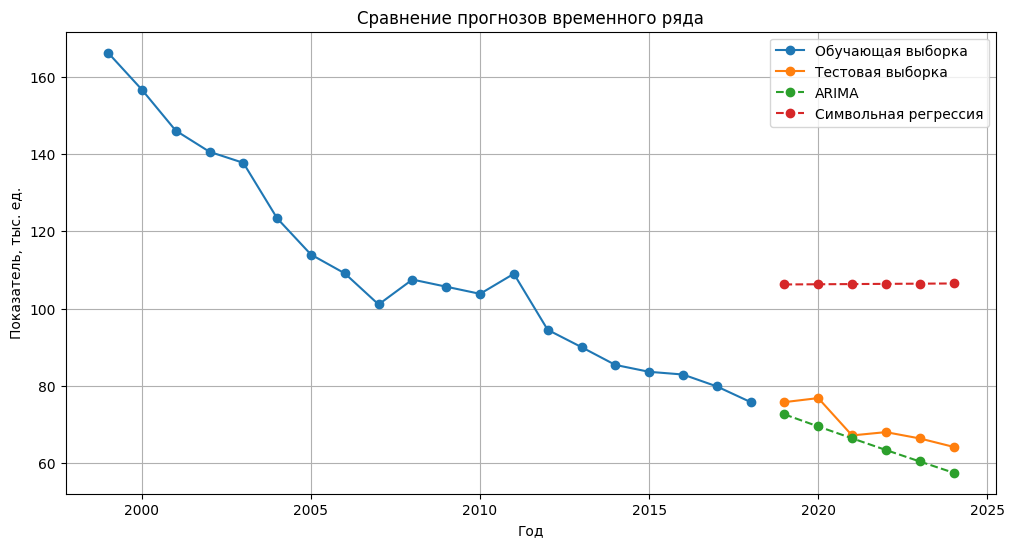

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(train['Год'], train['Показатель, тыс. ед.'], marker='o', label='Обучающая выборка')
plt.plot(test['Год'], test['Показатель, тыс. ед.'], marker='o', label='Тестовая выборка')

plt.plot(test['Год'], test['ARIMA_forecast'], marker='o', linestyle='--', label='ARIMA')
plt.plot(test['Год'], test['Symbolic_forecast'], marker='o', linestyle='--', label='Символьная регрессия')

if 'COMBI_forecast' in test.columns:
    plt.plot(test['Год'], test['COMBI_forecast'], marker='o', linestyle='--', label='COMBI')

if 'MIA_forecast' in test.columns:
    plt.plot(test['Год'], test['MIA_forecast'], marker='o', linestyle='--', label='MIA')

plt.title('Сравнение прогнозов временного ряда')
plt.xlabel('Год')
plt.ylabel('Показатель, тыс. ед.')
plt.legend()
plt.grid(True)
plt.show()

## 11. Оценка качества прогнозов

Для оценки качества используются метрики:

- **MAE** — средняя абсолютная ошибка;
- **RMSE** — корень из среднеквадратичной ошибки.

Чем меньше значения этих метрик, тем точнее прогноз.

In [15]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

metrics = []

mae, rmse = calculate_metrics(test['Показатель, тыс. ед.'], test['ARIMA_forecast'])
metrics.append(['ARIMA', mae, rmse])

mae, rmse = calculate_metrics(test['Показатель, тыс. ед.'], test['Symbolic_forecast'])
metrics.append(['Символьная регрессия', mae, rmse])

if 'COMBI_forecast' in test.columns:
    mae, rmse = calculate_metrics(test['Показатель, тыс. ед.'], test['COMBI_forecast'])
    metrics.append(['COMBI', mae, rmse])

if 'MIA_forecast' in test.columns:
    mae, rmse = calculate_metrics(test['Показатель, тыс. ед.'], test['MIA_forecast'])
    metrics.append(['MIA', mae, rmse])

metrics_df = pd.DataFrame(metrics, columns=['Метод', 'MAE', 'RMSE'])
metrics_df = metrics_df.sort_values(by='MAE').reset_index(drop=True)

print('Итоговая таблица качества прогнозов:')
print(metrics_df)

Итоговая таблица качества прогнозов:
                  Метод        MAE       RMSE
0                 ARIMA   4.753563   5.260333
1  Символьная регрессия  36.620993  36.944296


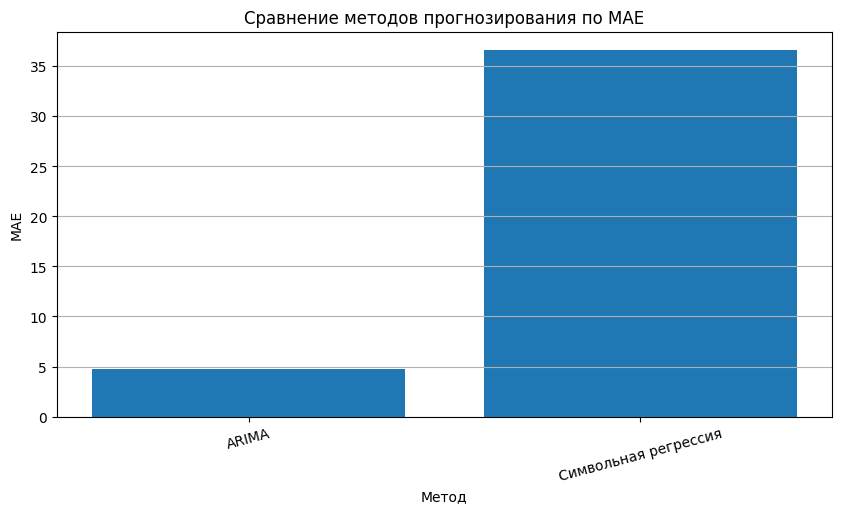

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(metrics_df['Метод'], metrics_df['MAE'])
plt.title('Сравнение методов прогнозирования по MAE')
plt.xlabel('Метод')
plt.ylabel('MAE')
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.show()

## 12. Вывод

В ходе лабораторной работы был выполнен анализ и прогнозирование временного ряда на основе данных `agriculture.csv`. Временной ряд был сформирован по годам для выбранного вида сельскохозяйственной продукции. После визуализации ряда и анализа его основных характеристик данные были разделены на обучающую и тестовую выборки без перемешивания, так как для временных рядов важен порядок наблюдений.

Для прогнозирования были использованы метод ARIMA, символьная регрессия, а также методы семейства МГУА COMBI и MIA при доступности библиотеки `gmdh`. Качество прогнозов оценивалось с помощью метрик MAE и RMSE. По результатам сравнения можно определить метод, показавший наименьшую ошибку прогноза на тестовой выборке.